## import necessary libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

## lets load the Boston Housing Dataset


In [2]:
data_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
raw_df = pd.read_csv(data_url)

In [3]:
print(raw_df)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio       b  lstat  medv  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14  21.6  
2       17.8  3


## lets prepare the dataset

In [4]:
df = pd.DataFrame(raw_df)
df = df.rename(columns={"medv":"price"})
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## dataset info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  price    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## check missing values

In [7]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
price      0
dtype: int64

### Exploraratory data analysis
## correlation

In [8]:

df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


### we can clearly see that while the crime rate is increasing the price of the house is decreasing

Text(0, 0.5, 'price')

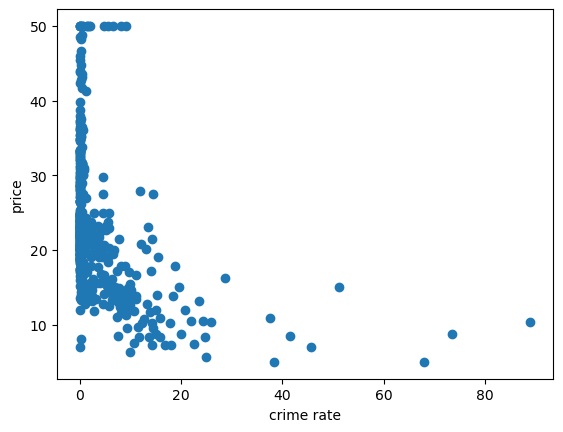

In [9]:
plt.scatter(df["crim"],df["price"])
plt.xlabel("crime rate")
plt.ylabel("price")

### plotting regression plots

<Axes: xlabel='rm', ylabel='price'>

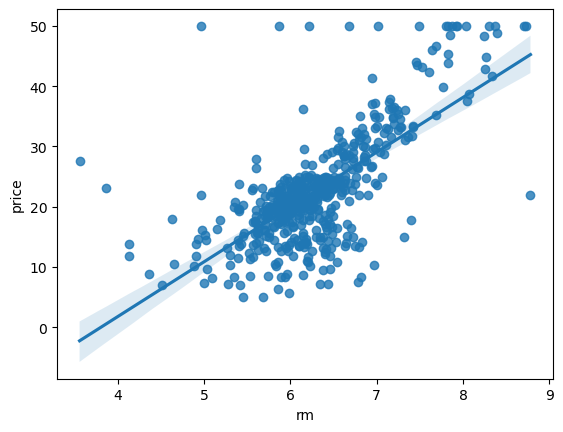

In [10]:
import seaborn as sns
sns.regplot(x="rm",y="price",data=df)

<Axes: xlabel='lstat', ylabel='price'>

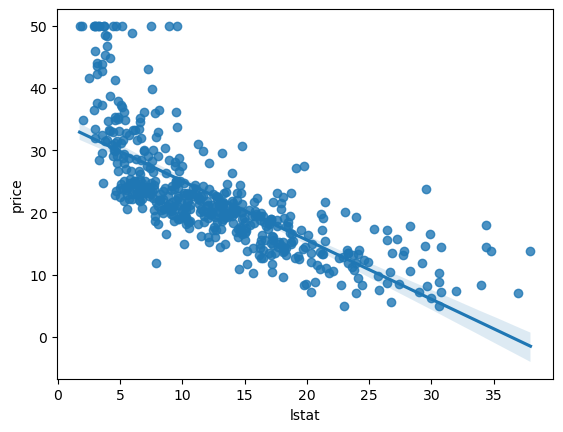

In [11]:
sns.regplot(x="lstat",y="price",data=df)

In [12]:
### dependent and independent features

X = df.iloc[:,:-1]
Y = df.iloc[:,-1]
X.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=8)


In [14]:
X_train


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
17,0.78420,0.0,8.14,0,0.538,5.990,81.7,4.2579,4,307,21.0,386.75,14.67
84,0.05059,0.0,4.49,0,0.449,6.389,48.0,4.7794,3,247,18.5,396.90,9.62
396,5.87205,0.0,18.10,0,0.693,6.405,96.0,1.6768,24,666,20.2,396.90,19.37
141,1.62864,0.0,21.89,0,0.624,5.019,100.0,1.4394,4,437,21.2,396.90,34.41
294,0.08199,0.0,13.92,0,0.437,6.009,42.3,5.5027,4,289,16.0,396.90,10.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,0.32982,0.0,21.89,0,0.624,5.822,95.4,2.4699,4,437,21.2,388.69,15.03
361,3.83684,0.0,18.10,0,0.770,6.251,91.1,2.2955,24,666,20.2,350.65,14.19
497,0.26838,0.0,9.69,0,0.585,5.794,70.6,2.8927,6,391,19.2,396.90,14.10
340,0.06151,0.0,5.19,0,0.515,5.968,58.5,4.8122,5,224,20.2,396.90,9.29


### standardization

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
import pickle
pickle.dump(scaler,open("scaling.pkl","wb"))
X_train

array([[-0.31618333, -0.46539892, -0.47321066, ...,  1.15754675,
         0.33802423,  0.26610019],
       [-0.39572906, -0.46539892, -1.00836053, ..., -0.02253489,
         0.44487484, -0.44799278],
       [ 0.23549504, -0.46539892,  0.98708873, ...,  0.77992063,
         0.44487484,  0.93070157],
       ...,
       [-0.37211397, -0.46539892, -0.24595523, ...,  0.30788797,
         0.44487484,  0.1854996 ],
       [-0.394545  , -0.46539892, -0.90572905, ...,  0.77992063,
         0.44487484, -0.49465628],
       [ 0.18877123, -0.46539892,  0.98708873, ...,  0.77992063,
         0.00683997,  0.69879811]], shape=(354, 13))

### Model Training


In [16]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
## print the coefficient and intercept
print(regression.coef_)

[-1.00464418  1.23083231  0.15987489  0.63763569 -1.38573398  2.6059672
 -0.24078768 -2.85356993  2.36796725 -1.88110753 -1.9795268   1.00469756
 -3.95921224]


In [18]:
print(regression.intercept_)

22.411581920903952


In [19]:
## on which params the model has been trained
print(regression.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


## Prediction with the test data

In [20]:
reg_pred = regression.predict(X_test)
reg_pred

array([19.36667199, 10.90135199, 38.22183643, 27.23008993, 40.86360853,
       27.462814  , 10.70895753, 36.33985245, 29.06780771, 34.65889684,
       13.06383643,  7.48552506, 15.30594202, 24.25609261, 15.7326924 ,
       28.85469028, 23.04674454, 22.4756561 , 21.13184502,  7.04408666,
       21.2118773 , 25.79184486, 30.52378626, 33.20341621, 28.66897069,
       35.44676805,  5.18094668, 14.36500631, 25.3635775 , 23.47314327,
       34.76079769, 18.53634825, 19.3854543 , 22.62515352, 25.72569699,
       27.00326966, 32.77697248, 25.60236289, 14.17206244, 14.13144421,
       21.53407601, 22.06013745, 36.0022969 , 35.29690286, 23.51437086,
       19.59457401, 19.9447559 , 21.21333233, 25.9417255 , 24.31696286,
       20.3417074 , 16.57330724, 32.43896087, 16.28495814, 22.30364436,
       24.79835447, 20.81794378,  5.29117863, 20.08017474, 28.56185743,
       24.7867144 , 21.73890171, 20.53304151,  8.69947126, 13.85691136,
       17.77498272, 12.76563098, 20.30967384, 35.36378927, 35.64

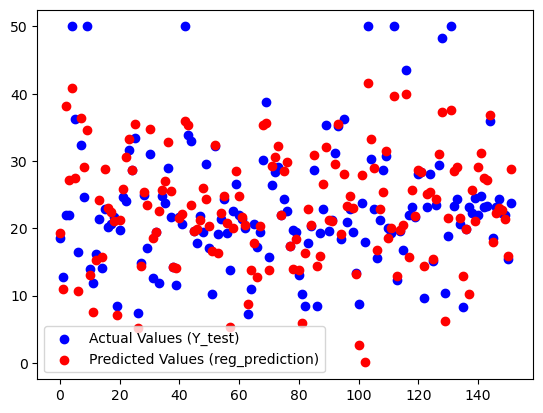

In [21]:


plt.scatter(range(len(Y_test)), Y_test, color='blue', label='Actual Values (Y_test)')
plt.scatter(range(len(reg_pred)), reg_pred, color='red', label='Predicted Values (reg_prediction)')
plt.legend()


In [22]:
residuals = Y_test-reg_pred
residuals


337    -0.866672
30      1.798648
364   -16.321836
240    -5.230090
162     9.136391
         ...    
208     1.341943
333    -0.487737
67      0.637215
149    -0.479100
238    -5.117530
Name: price, Length: 152, dtype: float64

### plotting residuals

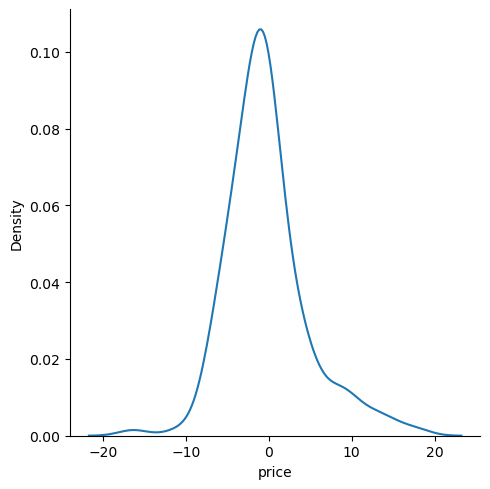

In [23]:
sns.displot(residuals,kind="kde")

### performance metrics

In [24]:
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error
print(mean_squared_error(Y_test,reg_pred))
print(mean_absolute_error(Y_test,reg_pred))


23.716180926283556
3.453292655262333


In [25]:
## R square
from sklearn.metrics import r2_score
score = r2_score(Y_test,reg_pred)
score


0.7080516940202748

## pickling the model for deployment

In [26]:
import pickle
pickle.dump(regression,open("regmodel.pkl","wb"))

In [27]:
pickled_model = pickle.load(open("regmodel.pkl","rb"))
pickled_model.predict(scaler.transform(np.array(X.iloc[0]).reshape(1,-1)))

/usr/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([30.52378626])